In [ ]:
#
# Project:
#      PyTorch Dojo (https://github.com/wo3kie/ml-dojo)
#
# Author:
#      Lukasz Czerwinski (https://www.lukaszczerwinski.pl/)
#

In [ ]:
import torch as tr

import import_ipynb
from per_lin_sig_bce_backward import Per_Lin_Sig_BCE_Backward # type: ignore
from per_lin_tanh_bce_backward import Per_Lin_Tanh_BCE_Backward # type: ignore

import matplotlib.pyplot as plt

In [ ]:
def plot_boolean_function(title, bool_fn, *args):
    x = tr.tensor([0, 0, 1, 1], dtype=tr.float32)
    y = tr.tensor([0, 1, 0, 1], dtype=tr.float32)
    z = tr.tensor([bool_fn(x[i], y[i]).item() for i in range(4)], dtype=tr.bool)

    plt.title(title)
    
    plt.xlabel('x')
    plt.xlim(-0.5, 1.5)
    plt.ylabel('y')
    plt.ylim(-0.5, 1.5)

    plt.scatter(x[z], y[z], color="green")
    plt.scatter(x[~z], y[~z], color="red")

    line_x = tr.tensor([-0.5, 1.5], dtype=tr.float32)
    line_y = args[0] * line_x + args[1]
    plt.plot(line_x, line_y, color= "0.9")

    if len(args) == 4:
        line_y = args[0] * line_x + args[1]
        plt.plot(line_x, line_y, color="0.7")

    if len(args) == 6:
        line_y = args[0] * line_x + args[1]
        plt.plot(line_x, line_y, color="0.5")

    plt.legend(['1', '0'], loc='upper left')
    plt.show()


In [ ]:
def learn_perceptron_xy(perceptron_type, x, y, epochs=500, lr=0.1):
    model = perceptron_type(2, 1)
    optimizer = tr.optim.SGD(model.parameters(), lr=lr)

    for _ in range(epochs):
        optimizer.zero_grad()
        loss = model.learn(x, y)
        loss.backward()
        optimizer.step()

    with tr.no_grad():
        weight = model.linear.weight[0].clone().detach().float()
        bias = model.linear.bias[0].clone().detach().float()

        return (weight, bias)

def learn_perceptron_boolean(perceptron_type, bool_fn, samples=100, epochs=500, lr=0.1):
    x = (tr.randn(samples, 2, dtype=tr.float32) > 0).float()
    y = bool_fn(x[:, 0], x[:, 1]).float().unsqueeze(1)
    return learn_perceptron_xy(perceptron_type, x, y, epochs, lr)

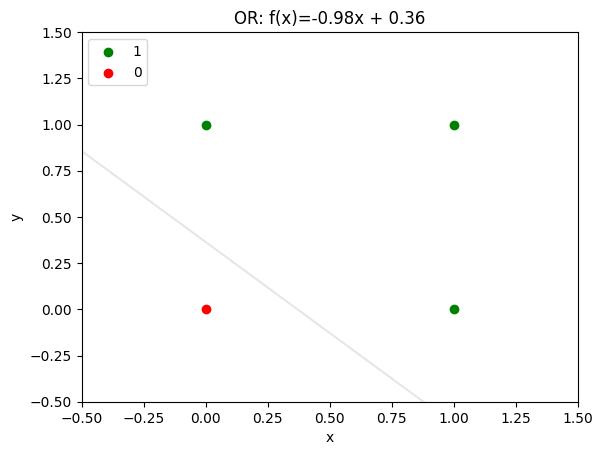

In [ ]:
bool_fn = tr.logical_or
((w1, w2), b) = learn_perceptron_boolean(Per_Lin_Tanh_BCE_Backward, bool_fn, epochs=500)
plot_boolean_function(f'OR: f(x)={-w1/w2:.2f}x + {-b/w2:.2f}', bool_fn, -w1/w2, -b/w2)

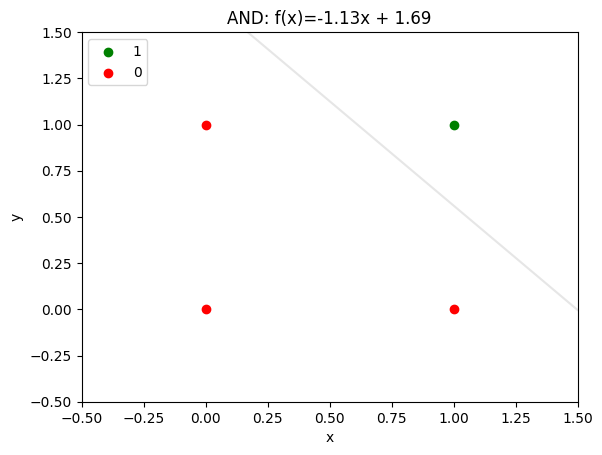

In [ ]:
bool_fn = tr.logical_and
((w1, w2), b) = learn_perceptron_boolean(Per_Lin_Tanh_BCE_Backward, bool_fn, epochs=500)
plot_boolean_function(f'AND: f(x)={-w1/w2:.2f}x + {-b/w2:.2f}', bool_fn, -w1/w2, -b/w2)

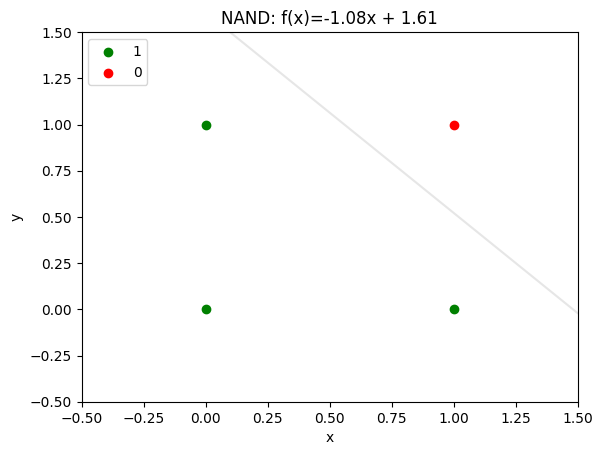

In [ ]:
bool_fn = lambda x, y: tr.logical_not(tr.logical_and(x, y))
((w1, w2), b) = learn_perceptron_boolean(Per_Lin_Tanh_BCE_Backward, bool_fn, epochs=500)
plot_boolean_function(f'NAND: f(x)={-w1/w2:.2f}x + {-b/w2:.2f}', bool_fn, -w1/w2, -b/w2)

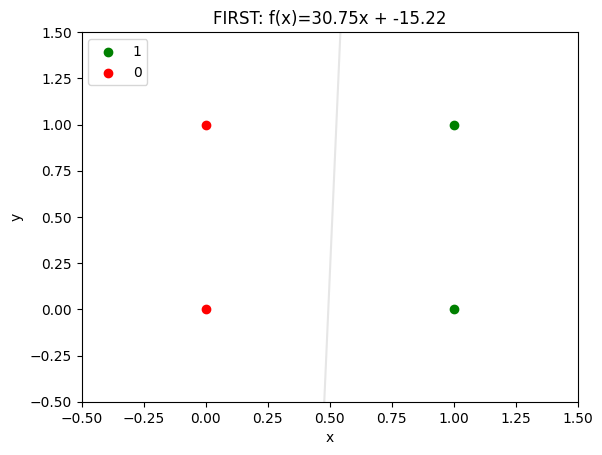

In [ ]:
bool_fn = lambda x, _: x
((w1, w2), b) = learn_perceptron_boolean(Per_Lin_Tanh_BCE_Backward, bool_fn, epochs=500)
plot_boolean_function(f'FIRST: f(x)={-w1/w2:.2f}x + {-b/w2:.2f}', bool_fn, -w1/w2, -b/w2)

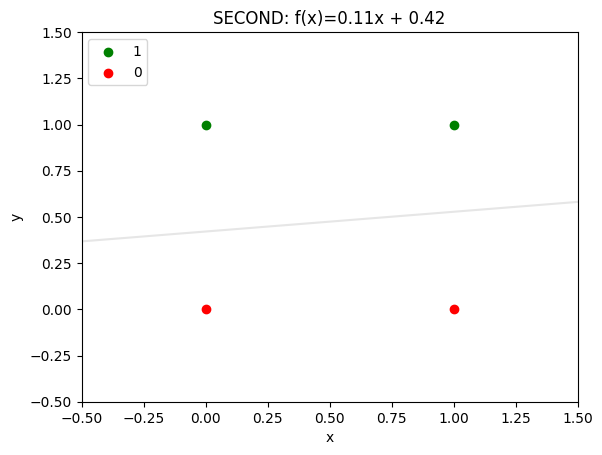

In [ ]:
bool_fn = lambda _, y: y
((w1, w2), b) = learn_perceptron_boolean(Per_Lin_Tanh_BCE_Backward, bool_fn, epochs=500)
plot_boolean_function(f'SECOND: f(x)={-w1/w2:.2f}x + {-b/w2:.2f}', bool_fn, -w1/w2, -b/w2)

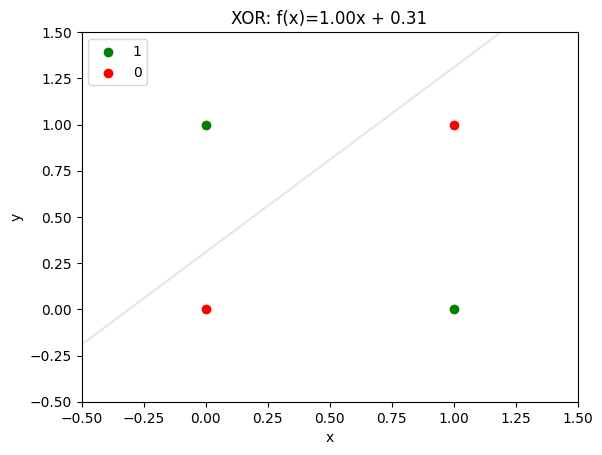

In [ ]:
bool_fn = tr.logical_xor
((w1, w2), b) = learn_perceptron_boolean(Per_Lin_Tanh_BCE_Backward, bool_fn, epochs=500)
plot_boolean_function(f'XOR: f(x)={-w1/w2:.2f}x + {-b/w2:.2f}', bool_fn, -w1/w2, -b/w2)